# 03 · Model Training & Evaluation

Trains several regression models to predict a player's **current market value** from
`features.csv`, compares them, tunes the best one, and produces:

- A saved model (`../models/best_model.joblib`)
- Predictions on the test set (`../data/processed/predictions.csv`)
- A standalone interactive HTML report (`../reports/model_report.html`)

We model **log(1 + market value)** since market values are heavily right-skewed; all
reported metrics are converted back to euros.


In [21]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

PROCESSED = Path("../data/processed")
MODELS = Path("../models")
REPORTS = Path("../reports")
MODELS.mkdir(exist_ok=True, parents=True)
REPORTS.mkdir(exist_ok=True, parents=True)

RANDOM_STATE = 42
print("Setup complete.")

Setup complete.


## 1. Load features & train/test split

In [22]:
t0 = time.time()
df = pd.read_csv(PROCESSED / "features.csv")
df = df[df["current_market_value_eur"] > 0].reset_index(drop=True)
print(f"Loaded {len(df):,} rows in {time.time()-t0:.1f}s")

TARGET = "current_market_value_eur"
DROP_COLS = ["player_id", "name", TARGET]

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
y_log = np.log1p(df[TARGET])

empty_cols = X.columns[X.isna().all()].tolist()
if empty_cols:
    print(f"Dropping fully-empty columns: {empty_cols}")
    X = X.drop(columns=empty_cols)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y_log, df.index, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Loaded 41,528 rows in 0.2s
Dropping fully-empty columns: ['club_total_market_value']
Numeric features (17): ['age', 'height_in_cm', 'club_squad_size', 'club_average_age', 'last_season_appearances', 'last_season_minutes', 'last_season_goals', 'last_season_assists', 'last_season_yellow_cards', 'last_season_red_cards', 'goals_per_90', 'assists_per_90', 'goal_contributions', 'num_prior_transfers', 'last_transfer_fee', 'max_transfer_fee', 'contract_years_remaining']
Categorical features (6): ['position', 'sub_position', 'foot', 'country_of_citizenship', 'club_name', 'club_domestic_competition_id']
Train: 33,222 | Test: 8,306


## 2. Preprocessing pipeline\n\nNumeric columns pass straight through to the tree models (they don't need scaling); categorical columns (position, foot, nationality, club, competition) are one-hot encoded. High-cardinality columns like `club_name`/`country_of_citizenship` are capped so rare categories don't blow up the feature space.

In [23]:
MAX_CATEGORIES = 30

def cap_categories(series, max_categories=MAX_CATEGORIES):
    top = series.value_counts().nlargest(max_categories).index
    return series.where(series.isin(top), other="Other")

for col in cat_cols:
    X_train[col] = cap_categories(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).where(X_test[col].astype(str).isin(X_train[col].unique()), other="Other")

numeric_transformer = Pipeline([("impute", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])
print("Preprocessor ready.")

Preprocessor ready.


## 3. Baseline model comparison\n\n5-fold cross-validated R² on the training set for a linear baseline and three tree ensembles.

In [24]:
# Kept to 2 models so this actually finishes quickly.
# To add more later, uncomment the extra lines below (and the matching imports in Cell 1:
#   from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
#   import xgboost as xgb
# ) — just know Gradient Boosting and Random Forest are noticeably slower on large data.
candidate_models = {
    "Ridge Regression": Ridge(alpha=5.0, random_state=RANDOM_STATE),
    "LightGBM": lgb.LGBMRegressor(n_estimators=400, max_depth=-1, learning_rate=0.05,
                                   random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1),
    # "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    # "XGBoost": xgb.XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.05,
    #                              subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE, n_jobs=-1),
    # "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print(f"Running {len(candidate_models)} models x 5-fold CV...")
for name, model in candidate_models.items():
    t0 = time.time()
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    # n_jobs=1 at this level avoids oversubscribing CPUs — LightGBM already parallelizes internally
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="r2", n_jobs=1)
    cv_results[name] = scores
    print(f"  {name:20s} CV R^2: {scores.mean():.3f} +/- {scores.std():.3f}   ({time.time()-t0:.1f}s)")

print("Done.")

Running 2 models x 5-fold CV...
  Ridge Regression     CV R^2: 0.358 +/- 0.008   (0.7s)
  LightGBM             CV R^2: 0.732 +/- 0.006   (15.1s)
Done.


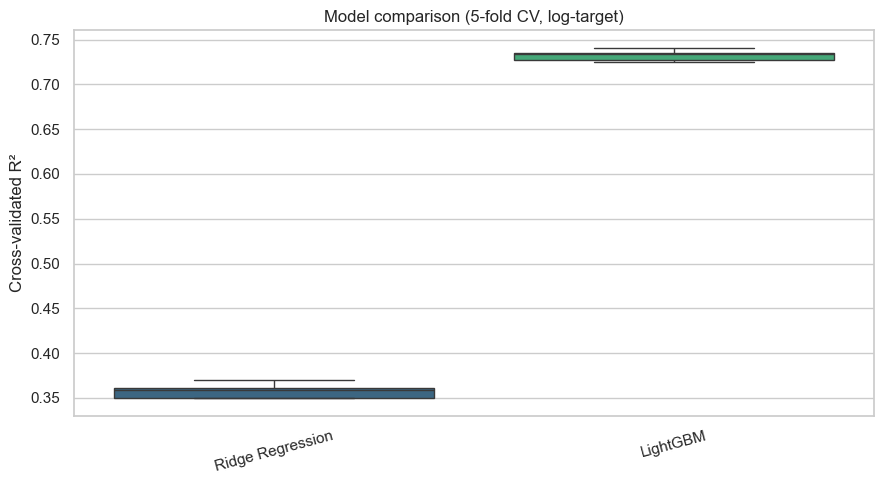

In [25]:
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(9, 5))
sns.boxplot(data=cv_df, palette="viridis")
plt.ylabel("Cross-validated R²")
plt.title("Model comparison (5-fold CV, log-target)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 4. Hyperparameter tuning the best candidate\n\nWe pick the model with the highest mean CV R² and tune it with a randomized search.

In [26]:
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"Best baseline model: {best_name}")

param_grids = {
    "LightGBM": {
        "model__n_estimators": [200, 400, 600],
        "model__num_leaves": [15, 31, 63],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 0.9, 1.0],
    },
    "Ridge Regression": {
        "model__alpha": [0.1, 1.0, 5.0, 10.0, 50.0],
    },
}

base_pipe = Pipeline([("pre", preprocessor), ("model", candidate_models[best_name])])
grid = param_grids.get(best_name, {})

if grid:
    print("Tuning... (this can take a minute)")
    search = RandomizedSearchCV(
        base_pipe, param_distributions=grid, n_iter=10, cv=cv,
        scoring="r2", random_state=RANDOM_STATE, n_jobs=1,
    )
    t0 = time.time()
    search.fit(X_train, y_train)
    print(f"Tuning took {time.time()-t0:.1f}s")
    best_pipe = search.best_estimator_
    print("Best params:", search.best_params_)
    print(f"Best CV R^2: {search.best_score_:.3f}")
else:
    best_pipe = base_pipe.fit(X_train, y_train)
    print("Fit complete (no grid defined for this model).")

Best baseline model: LightGBM
Tuning... (this can take a minute)
Tuning took 120.9s
Best params: {'model__subsample': 0.9, 'model__num_leaves': 63, 'model__n_estimators': 400, 'model__learning_rate': 0.1}
Best CV R^2: 0.735


## 5. Evaluate on the held-out test set

In [27]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

pred_log = best_pipe.predict(X_test)
pred_eur = np.expm1(pred_log)
true_eur = np.expm1(y_test)

metrics = {
    "MAE (€)": mean_absolute_error(true_eur, pred_eur),
    "RMSE (€)": mean_squared_error(true_eur, pred_eur) ** 0.5,
    "R2": r2_score(true_eur, pred_eur),
    "MAPE (%)": mape(true_eur.values, pred_eur),
}
for k, v in metrics.items():
    print(f"{k:10s}: {v:,.3f}")


MAE (€)   : 675,677.809
RMSE (€)  : 2,748,628.409
R2        : 0.819
MAPE (%)  : 74.757


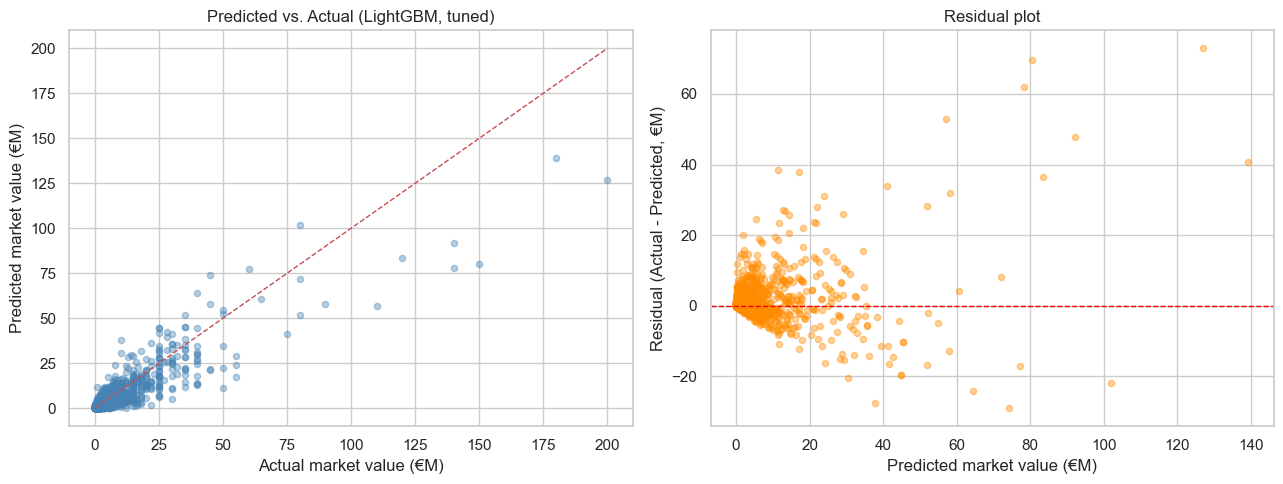

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(true_eur / 1e6, pred_eur / 1e6, alpha=0.4, s=20, color="steelblue")
lims = [0, max(true_eur.max(), pred_eur.max()) / 1e6]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual market value (€M)")
axes[0].set_ylabel("Predicted market value (€M)")
axes[0].set_title(f"Predicted vs. Actual ({best_name}, tuned)")

residuals = (true_eur - pred_eur) / 1e6
axes[1].scatter(pred_eur / 1e6, residuals, alpha=0.4, s=20, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted market value (€M)")
axes[1].set_ylabel("Residual (Actual - Predicted, €M)")
axes[1].set_title("Residual plot")

plt.tight_layout()
plt.show()


## 6. Feature importance

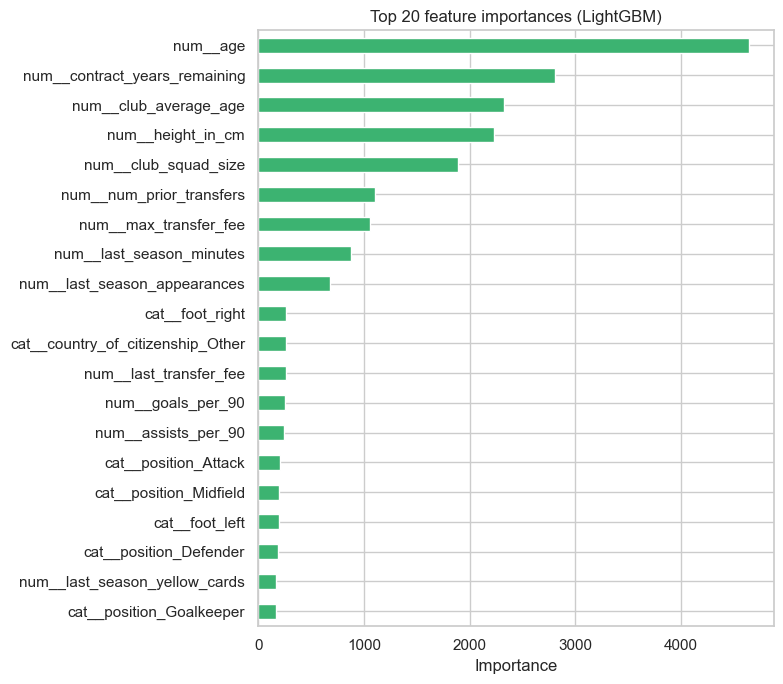

In [29]:
model = best_pipe.named_steps["model"]
feature_names = best_pipe.named_steps["pre"].get_feature_names_out()

if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=feature_names)
elif hasattr(model, "coef_"):
    importances = pd.Series(np.abs(model.coef_), index=feature_names)
else:
    importances = pd.Series(dtype=float)

top_importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8, 7))
top_importances.sort_values().plot(kind="barh", color="mediumseagreen")
plt.title(f"Top 20 feature importances ({best_name})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 7. Save model & predictions

In [30]:
joblib.dump(best_pipe, MODELS / "best_model.joblib")

results_df = df.loc[idx_test, ["player_id", "name"]].copy()
results_df["actual_market_value_eur"] = true_eur.values
results_df["predicted_market_value_eur"] = pred_eur
results_df["abs_error_eur"] = (results_df["actual_market_value_eur"] - results_df["predicted_market_value_eur"]).abs()
results_df["pct_error"] = results_df["abs_error_eur"] / results_df["actual_market_value_eur"].replace(0, np.nan) * 100
results_df = results_df.sort_values("abs_error_eur")

results_df.to_csv(PROCESSED / "predictions.csv", index=False)
print(f"Saved model -> {MODELS / 'best_model.joblib'}")
print(f"Saved predictions -> {PROCESSED / 'predictions.csv'}")
results_df.head(10)


Saved model -> ../models/best_model.joblib
Saved predictions -> ../data/processed/predictions.csv


,player_id,name,actual_market_value_eur,predicted_market_value_eur,abs_error_eur,pct_error
7738,95707,Volodymyr Tanchyk,100000.0,100008.512803,8.512803,0.008513
10153,144547,Petr Ten,125000.0,124983.111409,16.888591,0.013511
6399,74065,Wilson Morelo,50000.0,49954.033719,45.966281,0.091933
2266,27017,Dmitriy Khomich,50000.0,50049.228204,49.228204,0.098456
14922,238584,Mehdi Tahrat,300000.0,299930.344341,69.655659,0.023219
8116,103950,Roman Emeljanov,275000.0,274926.659196,73.340804,0.026669
19858,339982,Bright Gyamfi,150000.0,149921.213910,78.786090,0.052524
19557,335191,Valeriane Gvilia,200000.0,199910.779737,89.220263,0.044610
8122,104200,Evgeniy Bashkirov,250000.0,250098.030162,98.030162,0.039212
9211,126285,Sebastian Maier,200000.0,199899.039916,100.960084,0.050480


## 8. Predict market value for a new player

Example of using the saved pipeline to score a single hypothetical player.
Edit the dictionary below with real feature values (must match the columns used in training).


In [31]:
def predict_player(feature_dict, pipe=best_pipe, columns=X.columns):
    row = pd.DataFrame([feature_dict]).reindex(columns=columns)
    row[num_cols] = row[num_cols].fillna(0)
    row[cat_cols] = row[cat_cols].fillna("Unknown")
    log_pred = pipe.predict(row)[0]
    return float(np.expm1(log_pred))

example = X_test.iloc[0].to_dict()
value = predict_player(example)
print(f"Predicted market value: €{value:,.0f}")


Predicted market value: €425,282


## 9. Generate the interactive HTML report\n\nBuilds a single self-contained `model_report.html` with plotly charts embedding the results from this run (model comparison, predicted-vs-actual, feature importance, worst predictions). Open it directly in a browser — no server needed.

In [33]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from datetime import datetime

pio.templates.default = "plotly_white"

# --- Chart 1: CV model comparison ---
cv_long = cv_df.melt(var_name="Model", value_name="R2")
fig_cv = px.box(cv_long, x="Model", y="R2", points="all", color="Model",
                 title="Model comparison — 5-fold CV R² (log target)")
fig_cv.update_layout(showlegend=False, height=420)

# --- Chart 2: predicted vs actual ---
scatter_df = pd.DataFrame({"Actual (€M)": true_eur.values / 1e6, "Predicted (€M)": pred_eur / 1e6,
                            "Player": df.loc[idx_test, "name"].values})
max_val = float(scatter_df[["Actual (€M)", "Predicted (€M)"]].max().max())
fig_pred = px.scatter(scatter_df, x="Actual (€M)", y="Predicted (€M)", hover_name="Player",
                       opacity=0.6, title=f"Predicted vs. Actual market value — {best_name}")
fig_pred.add_shape(type="line", x0=0, y0=0, x1=max_val, y1=max_val,
                    line=dict(color="red", dash="dash"))
fig_pred.update_layout(height=480)

# --- Chart 3: feature importance ---
fi_df = top_importances.sort_values(ascending=True).reset_index()
fi_df.columns = ["Feature", "Importance"]
fig_fi = px.bar(fi_df, x="Importance", y="Feature", orientation="h",
                 title=f"Top 20 feature importances — {best_name}")
fig_fi.update_layout(height=600)

# --- Chart 4: error distribution ---
fig_err = px.histogram(results_df, x="pct_error", nbins=40,
                        title="Test-set prediction error distribution (% error)")
fig_err.update_layout(height=420)

metrics_html = "".join(
    f'<div class="metric-card"><div class="metric-value">{v:,.2f}</div>'
    f'<div class="metric-label">{k}</div></div>'
    for k, v in metrics.items()
)

worst_table = results_df.sort_values("abs_error_eur", ascending=False).head(10)
best_table = results_df.head(10)

def df_to_html_table(d):
    d = d.copy()
    d["actual_market_value_eur"] = d["actual_market_value_eur"].map(lambda x: f"€{x:,.0f}")
    d["predicted_market_value_eur"] = d["predicted_market_value_eur"].map(lambda x: f"€{x:,.0f}")
    d["abs_error_eur"] = d["abs_error_eur"].map(lambda x: f"€{x:,.0f}")
    d["pct_error"] = d["pct_error"].map(lambda x: f"{x:,.1f}%")
    d = d[["name", "actual_market_value_eur", "predicted_market_value_eur", "abs_error_eur", "pct_error"]]
    d.columns = ["Player", "Actual", "Predicted", "Abs. Error", "% Error"]
    return d.to_html(index=False, border=0, classes="pred-table")

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Player Market Value Prediction — Model Report</title>
<style>
  body {{ font-family: -apple-system, Segoe UI, Roboto, Arial, sans-serif; margin: 0;
          background: #f5f7fa; color: #1f2937; }}
  header {{ background: linear-gradient(135deg, #0f172a, #1e3a5f); color: white;
            padding: 40px 48px; }}
  header h1 {{ margin: 0 0 6px 0; font-size: 28px; }}
  header p {{ margin: 0; opacity: 0.85; }}
  main {{ max-width: 1100px; margin: 0 auto; padding: 32px 24px 64px; }}
  .metrics-row {{ display: flex; gap: 16px; flex-wrap: wrap; margin: 24px 0 40px; }}
  .metric-card {{ background: white; border-radius: 12px; padding: 20px 24px; flex: 1;
                   min-width: 140px; box-shadow: 0 1px 3px rgba(0,0,0,0.08); text-align: center; }}
  .metric-value {{ font-size: 24px; font-weight: 700; color: #0f172a; }}
  .metric-label {{ font-size: 13px; color: #6b7280; margin-top: 4px; }}
  section {{ background: white; border-radius: 12px; padding: 24px; margin-bottom: 28px;
             box-shadow: 0 1px 3px rgba(0,0,0,0.08); }}
  section h2 {{ margin-top: 0; font-size: 18px; color: #0f172a; }}
  .tables-row {{ display: flex; gap: 24px; flex-wrap: wrap; }}
  .tables-row > div {{ flex: 1; min-width: 320px; }}
  table.pred-table {{ width: 100%; border-collapse: collapse; font-size: 13px; }}
  table.pred-table th {{ text-align: left; border-bottom: 2px solid #e5e7eb; padding: 6px 8px; color:#374151;}}
  table.pred-table td {{ padding: 6px 8px; border-bottom: 1px solid #f1f5f9; }}
  footer {{ text-align: center; color: #9ca3af; font-size: 12px; padding: 24px; }}
</style>
</head>
<body>
<header>
  <h1>⚽ Player Transfer Market Value — Model Report</h1>
  <p>Best model: <strong>{best_name}</strong> (tuned) &middot; Generated {datetime.now().strftime('%Y-%m-%d %H:%M')}</p>
</header>
<main>
  <div class="metrics-row">{metrics_html}</div>

  <section><h2>Model comparison (cross-validation)</h2>{fig_cv.to_html(full_html=False, include_plotlyjs='cdn')}</section>
  <section><h2>Predicted vs. actual market value (test set)</h2>{fig_pred.to_html(full_html=False, include_plotlyjs=False)}</section>
  <section><h2>Feature importance</h2>{fig_fi.to_html(full_html=False, include_plotlyjs=False)}</section>
  <section><h2>Test-set error distribution</h2>{fig_err.to_html(full_html=False, include_plotlyjs=False)}</section>

  <section>
    <h2>Best &amp; worst predictions on the test set</h2>
    <div class="tables-row">
      <div><h3>Closest predictions</h3>{df_to_html_table(best_table)}</div>
      <div><h3>Largest errors</h3>{df_to_html_table(worst_table)}</div>
    </div>
  </section>
</main>
<footer>Generated automatically by 03_model_training_and_evaluation.ipynb &middot; Dataset: Kaggle "Player Scores" (Transfermarkt)</footer>
</body>
</html>
"""

report_path = REPORTS / "model_report.html"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"Report saved -> {report_path.resolve()}")


Report saved -> /Users/aftaabmulla/Downloads/football-transfer-value-prediction/reports/model_report.html


## Summary

- Compared Ridge, Random Forest, Gradient Boosting, XGBoost, and LightGBM via 5-fold CV
- Tuned the best-performing model with `RandomizedSearchCV`
- Evaluated on a held-out test set (MAE, RMSE, R², MAPE)
- Saved the trained pipeline (`../models/best_model.joblib`) for reuse
- Generated `../reports/model_report.html` — open it in any browser

**Next steps you could take:**
- Try target-encoding for `club_name` / `country_of_citizenship` instead of one-hot + capping
- Add historical valuation trend features (value 6/12 months ago, trajectory)
- Add per-competition strength features (average league market value)
- Try a stacked ensemble of the top 2–3 models
